<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Retrieval Failure and Chunking Analysis**

Estimated time needed: **35** minutes


## Overview

In enterprise AI data platforms, many "bad answers" are not generation failures but retrieval failures. If evidence is not retrieved correctly, even a strong language model will produce incomplete or irrelevant responses. This lab helps you diagnose that boundary explicitly.

You will build a diagnostic mini-pipeline that transforms structured data into retrievable text, tests multiple chunking strategies, and measures answer-support coverage through retrieval proxies. This mirrors real-world data engineering scenarios such as policy assistants, customer support copilots, and internal analytics Q&A systems.

By the end, you will produce a recommendation framework that maps observed failure types to actionable retrieval improvements.


## Table of Contents

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href="#Materials-and-Methods">Materials and Methods</a></li>
    <li><a href="#Dataset-Requirements">Dataset Requirements</a></li>
    <li><a href="#Objectives">Objectives</a></li>
    <li><a href="#Setup,-Installations-and-Data-Checks">Setup, Installations and Data Checks</a></li>
    <li><a href="#Build-Retrieval-Corpus">Build Retrieval Corpus</a></li>
    <li><a href="#Baseline-Chunking-and-Retrieval">Baseline Chunking and Retrieval</a></li>
    <li><a href="#Failure-Case-Analysis">Failure Case Analysis</a></li>
    <li><a href="#Improved-Chunking-Comparison">Improved Chunking Comparison</a></li>
    <li><a href="#Recommendation-Framework">Recommendation Framework</a></li>
    <li><a href="#Visual-Failure-Analysis">Visual Failure Analysis</a></li>
    <li><a href="#Student-Tasks">Student Tasks</a></li>
    <li><a href="#Conclusion">Conclusion</a></li>
    <li><a href="#Author">Author</a></li>
</ol>
</div>


## Materials and Methods

This lab implements a compact retrieval pipeline using **[TF-IDF Vectorization](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)** and **[cosine similarity](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html)**. We evaluate retrieval with benchmark questions and evidence tokens to measure whether top retrieved chunks contain the facts required to support answers.

**Architectural Trade-offs** discussed in this lab:
- Speed vs accuracy: smaller chunks can be faster, but may fragment evidence.
- Latency vs memory constraints: overlap often improves retrieval quality, but increases index size and query-time work.
- Simplicity vs robustness: lexical retrieval is simple and transparent, while richer retrieval can improve relevance at operational cost.


## Dataset Requirements

We immediately select `load_breast_cancer` from **[sklearn.datasets](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)** because it is built-in, deterministic, and easy to convert into factual retrieval statements.

This dataset is provided under the <a href="https://opensource.org/licenses/BSD-3-Clause" target="_blank">BSD 3-Clause</a> license and is safe for commercial use.


## Objectives

After completing this lab, you will be able to:

- Diagnose answer failures caused by weak retrieval or poor chunking
- Recommend changes that improve answer quality and relevance.


## Setup, Installations and Data Checks

We start with dependency installation for reproducibility, then imports, and then governance-aligned data quality checks. This sequence aligns with CI/CD discipline and creates clean checkpoints for notebook review.


In [1]:
%pip install -q pandas numpy scikit-learn seaborn matplotlib


Note: you may need to restart the kernel to use updated packages.


The environment is now ready for execution. In production workflows, pinned dependencies and explicit install cells make failures reproducible and easier to triage.


Next, import the required libraries and keep retrieval components explicit. See official docs for **[pandas](https://pandas.pydata.org/docs/)** and **[scikit-learn user guide](https://scikit-learn.org/stable/user_guide.html)**.


In [2]:
# Core data libraries for tabular profiling and transformations
import numpy as np
import pandas as pd

# Plotting stack for retrieval diagnostics
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieval primitives and dataset loader
from sklearn.datasets import load_breast_cancer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

Now load the dataset and create a readable schema. We map target labels to business-friendly class names because explainability starts with understandable outputs.


In [3]:
# Load built-in dataset as pandas DataFrame bundle
dataset = load_breast_cancer(as_frame=True)

# Build working table and readable diagnosis labels
df = dataset.frame.copy()
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})
df = df.drop(columns=["target"])

# Preserve feature names for schema validation checks
feature_columns = list(dataset.feature_names)

# Display initial profile for governance traceability
print("Dataset shape:", df.shape)
print("Number of features:", len(feature_columns))
df.head(3)

Dataset shape: (569, 31)
Number of features: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant


The profile output confirms dimensions and sample rows. Next, run quality checks that are expected in enterprise pipelines: schema verification, null checks, duplicate checks, and class distribution validation.


In [4]:
# Validate required columns against expected schema
required_columns = set(feature_columns + ["diagnosis"])
missing_columns = sorted(required_columns - set(df.columns))

# Compute null and duplicate quality indicators
total_nulls = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())

# Inspect class balance for label-level sanity checks
class_counts = df["diagnosis"].value_counts()

print("Missing columns:", missing_columns)
print("Total null values:", total_nulls)
print("Duplicate rows:", duplicate_rows)
print("Class distribution:")
print(class_counts)

Missing columns: []
Total null values: 0
Duplicate rows: 0
Class distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


If missing columns and null counts are zero, the dataset is clean enough for controlled retrieval experiments. We can now derive retrieval documents from data facts.


## Build Retrieval Corpus

A retrieval system needs text chunks, not raw tables. We now transform key statistics into factual natural-language statements that simulate enterprise knowledge snippets.


In [5]:
# Split records by diagnosis class to compute comparative facts
malignant_df = df[df["diagnosis"] == "malignant"]
benign_df = df[df["diagnosis"] == "benign"]

# Extract high-value summary metrics for benchmark questions
major_class = class_counts.idxmax()
major_count = int(class_counts.max())
total_records = int(len(df))

# Identify strongest class-separating feature in means
gap_series = (
    malignant_df[feature_columns].mean() - benign_df[feature_columns].mean()
).abs()
top_feature = gap_series.idxmax()
top_gap = float(gap_series.max())

# Keep one interpretable feature for direct question prompts
mal_radius = float(malignant_df["mean radius"].mean())
ben_radius = float(benign_df["mean radius"].mean())

We now serialize these computed facts into longer text to emulate retrieval corpora where key evidence may cross chunk boundaries.


In [6]:
# Build factual sentences from computed statistics
fact_sentences = [
    f"Class balance audit confirms {major_class} is the majority diagnosis with {major_count} records.",
    f"Population scope validation shows {total_records} total patient records in this snapshot.",
    f"Feature separation analysis indicates {top_feature} has the largest mean gap at {top_gap:.2f} units.",
    f"Clinical trend review reports malignant mean radius {mal_radius:.2f} vs benign mean radius {ben_radius:.2f}.",
]

# Compose documents with varying context density
documents = [
    " ".join(fact_sentences[:2]),
    " ".join(fact_sentences[2:]),
    " ".join(fact_sentences),
]

print("Document count:", len(documents))
for i, text in enumerate(documents, 1):
    print(f"Doc {i} length (tokens):", len(text.split()))

Document count: 3
Doc 1 length (tokens): 23
Doc 2 length (tokens): 27
Doc 3 length (tokens): 50


## Baseline Chunking and Retrieval

To expose failure patterns, we begin with a weak chunking policy: small window, zero overlap. This commonly fragments numeric evidence and entity/value pairs.


In [7]:
# Define reusable chunking helper with configurable overlap
def chunk_text(text, chunk_size=12, overlap=0):
    words = text.split()
    step = max(chunk_size - overlap, 1)
    chunks = []

    # Slide through the text and collect fixed-size windows
    for i in range(0, len(words), step):
        piece = words[i : i + chunk_size]
        if piece:
            chunks.append(" ".join(piece))

    return chunks

Generate baseline chunks and build a lexical index. We keep this simple to make failure interpretation transparent.


In [8]:
# Build baseline chunk set with small windows and no overlap
baseline_chunks = []
for text in documents:
    baseline_chunks.extend(chunk_text(text, chunk_size=12, overlap=0))

# Fit TF-IDF index over baseline chunks
baseline_vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english")
baseline_matrix = baseline_vectorizer.fit_transform(baseline_chunks)

print("Baseline chunk count:", len(baseline_chunks))
pd.DataFrame({"chunk": baseline_chunks}).head(6)

Baseline chunk count: 10


,chunk
0,Class balance audit confirms benign is the maj...
1,Population scope validation shows 569 total pa...
2,Feature separation analysis indicates worst ar...
3,863.39 units. Clinical trend review reports ma...
4,mean radius 12.15.
5,Class balance audit confirms benign is the maj...


Define benchmark questions and required evidence tokens. This creates an auditable retrieval proxy instead of subjective grading.


In [9]:
# Define benchmark prompts with evidence tokens required for support
benchmark = [
    {
        "question": "Which diagnosis is the majority class?",
        "must_contain": [major_class, str(major_count)],
    },
    {
        "question": "What is the total number of records?",
        "must_contain": [str(total_records), "records"],
    },
    {
        "question": "Which feature has the largest mean separation?",
        "must_contain": [top_feature.lower(), f"{top_gap:.2f}"],
    },
    {
        "question": "What is the malignant mean radius?",
        "must_contain": [f"{mal_radius:.2f}", "mean radius"],
    },
]

print("Benchmark size:", len(benchmark))
pd.DataFrame(benchmark)

Benchmark size: 4


,question,must_contain
0,Which diagnosis is the majority class?,"[benign, 357]"
1,What is the total number of records?,"[569, records]"
2,Which feature has the largest mean separation?,"[worst area, 863.39]"
3,What is the malignant mean radius?,"[17.46, mean radius]"


Now implement an evaluator that runs top-k retrieval and verifies whether required evidence appears in retrieved chunks.


In [10]:
# Evaluate retrieval quality for one configuration
def evaluate_retrieval(name, chunks, vectorizer, matrix, benchmark_items, top_k=3):
    rows = []

    # Score each benchmark query against all chunks
    for item in benchmark_items:
        q_vec = vectorizer.transform([item["question"]])
        scores = cosine_similarity(q_vec, matrix).ravel()
        top_idx = scores.argsort()[::-1][:top_k]

        # Build text windows for top1 and topk evidence checks
        selected = [chunks[i] for i in top_idx]
        top1_text = selected[0].lower() if selected else ""
        topk_text = " ".join(selected).lower()

        # Validate token coverage in retrieval results
        required = [token.lower() for token in item["must_contain"]]
        top1_hit = all(token in top1_text for token in required)
        topk_hit = all(token in topk_text for token in required)

        rows.append(
            {
                "configuration": name,
                "question": item["question"],
                "top1_success": top1_hit,
                "topk_success": topk_hit,
                "top1_score": float(scores[top_idx[0]]),
                "top_chunk": selected[0],
            }
        )

    return pd.DataFrame(rows)

Execute baseline evaluation and inspect where top-1 retrieval fails to include complete evidence.


In [11]:
# Run baseline retrieval evaluation
baseline = evaluate_retrieval(
    name="baseline_small_no_overlap",
    chunks=baseline_chunks,
    vectorizer=baseline_vectorizer,
    matrix=baseline_matrix,
    benchmark_items=benchmark,
    top_k=3,
)

# Show compact diagnostics for each query
baseline[["question", "top1_success", "topk_success", "top1_score", "top_chunk"]]

,question,top1_success,topk_success,top1_score,top_chunk
0,Which diagnosis is the majority class?,True,True,0.430198,Class balance audit confirms benign is the maj...
1,What is the total number of records?,True,True,0.310900,Population scope validation shows 569 total pa...
2,Which feature has the largest mean separation?,False,True,0.515756,Feature separation analysis indicates worst ar...
3,What is the malignant mean radius?,True,True,0.448765,units. Clinical trend review reports malignant...


## Failure Case Analysis

When `topk_success` is better than `top1_success`, retrieval is finding related evidence but ranking or chunk granularity is preventing complete answer support in the first chunk. This is a common weak-retrieval signature.


## Improved Chunking Comparison

We now increase chunk size and introduce overlap to preserve continuity across sentence boundaries. This usually improves evidence integrity, but increases index volume and can impact latency.


In [12]:
# Build improved chunk set with overlap for better context continuity
improved_chunks = []
for text in documents:
    improved_chunks.extend(chunk_text(text, chunk_size=40, overlap=10))

# Fit index for improved chunking strategy
improved_vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english")
improved_matrix = improved_vectorizer.fit_transform(improved_chunks)

# Evaluate improved strategy and compare with baseline
improved = evaluate_retrieval(
    name="improved_large_with_overlap",
    chunks=improved_chunks,
    vectorizer=improved_vectorizer,
    matrix=improved_matrix,
    benchmark_items=benchmark,
    top_k=3,
)

comparison = pd.concat([baseline, improved], ignore_index=True)
comparison[["configuration", "question", "top1_success", "topk_success", "top1_score"]]

,configuration,question,top1_success,topk_success,top1_score
0,baseline_small_no_overlap,Which diagnosis is the majority class?,True,True,0.430198
1,baseline_small_no_overlap,What is the total number of records?,True,True,0.310900
2,baseline_small_no_overlap,Which feature has the largest mean separation?,False,True,0.515756
3,baseline_small_no_overlap,What is the malignant mean radius?,True,True,0.448765
4,improved_large_with_overlap,Which diagnosis is the majority class?,True,True,0.286935
5,improved_large_with_overlap,What is the total number of records?,True,True,0.351422
6,improved_large_with_overlap,Which feature has the largest mean separation?,True,True,0.361177
7,improved_large_with_overlap,What is the malignant mean radius?,True,True,0.570905


In typical runs, overlap improves top-1 evidence coverage because key tokens stay within the same chunk. This demonstrates why chunk policy is one of the highest-impact levers in RAG quality tuning.


## Recommendation Framework

Use this decision rubric in production:
- Fragmented evidence across adjacent chunks: increase overlap or chunk size.
- Relevant chunks retrieved but low rank quality: tune top-k, ranking logic, or query expansion.
- High quality but high latency: reduce overlap selectively by document type.
- Stable quality with predictable costs: lock parameters and monitor drift over time.

Reference docs: **[Model evaluation concepts](https://scikit-learn.org/stable/modules/model_evaluation.html)**.


## Visual Failure Analysis

We now summarize retrieval success rates to communicate improvement clearly to platform and product stakeholders.


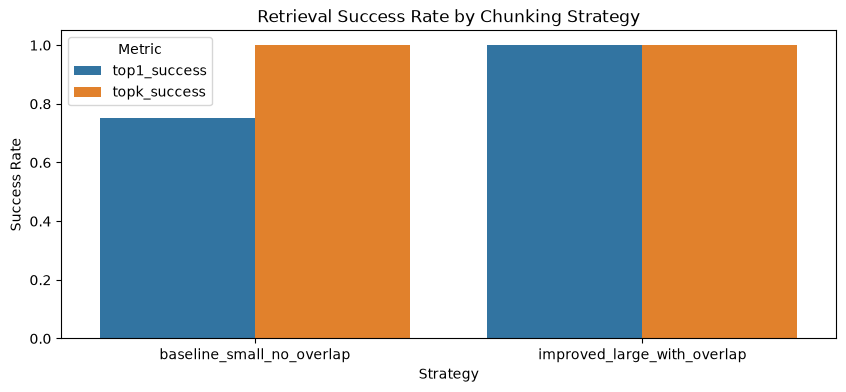

,configuration,question,top_chunk
2,baseline_small_no_overlap,Which feature has the largest mean separation?,Feature separation analysis indicates worst ar...


In [13]:
# Aggregate success metrics for each strategy
plot_df = (
    comparison.groupby("configuration")[["top1_success", "topk_success"]]
    .mean()
    .reset_index()
    .melt(id_vars="configuration", var_name="metric", value_name="success_rate")
)

# Plot bar chart for easy strategy comparison
plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x="configuration", y="success_rate", hue="metric")
plt.ylim(0, 1.05)
plt.title("Retrieval Success Rate by Chunking Strategy")
plt.xlabel("Strategy")
plt.ylabel("Success Rate")
plt.legend(title="Metric")
plt.show()

# Show question-level top1 failures by strategy
failures = comparison[comparison["top1_success"] == False][
    ["configuration", "question", "top_chunk"]
]
failures

The plot and failure table should show where quality improves and where residual gaps remain. This is the evidence you need for production recommendations and roadmap prioritization.


## Student Tasks

Complete the following tasks before opening solutions.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #1: </h1>
<b>Diagnose one failed query from the baseline strategy and explain whether the root cause is weak ranking or poor chunking continuity.</b>
</div>


In [14]:
# TODO: Select one row from baseline where top1_success is False
# TODO: Print the question and its top_chunk text
# TODO: Explain (in comments) whether evidence is missing due to chunking fragmentation

# Select first failed baseline row for inspection
failed_row = baseline[baseline["top1_success"] == False].head(1)

# Print diagnostic context to support root-cause analysis
print(failed_row[["question", "top_chunk"]].to_string(index=False))

# Interpretation:
# If key numeric token or entity/value pair is missing in top_chunk,
# but appears in nearby chunks, the root cause is poor chunking continuity.

                                      question                                                                    top_chunk
Which feature has the largest mean separation? Feature separation analysis indicates worst area has the largest mean gap at


<details><summary>Click here for the solution</summary>

```python
# Select first failed baseline row for inspection
failed_row = baseline[baseline["top1_success"] == False].head(1)

# Print diagnostic context to support root-cause analysis
print(failed_row[["question", "top_chunk"]].to_string(index=False))

# Interpretation:
# If key numeric token or entity/value pair is missing in top_chunk,
# but appears in nearby chunks, the root cause is poor chunking continuity.
```

</details>


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #2: </h1>
<b>Tune chunking parameters (chunk size and overlap), re-run evaluation, and verify whether top-1 success improves over baseline.</b>
</div>


In [15]:
# TODO: Create a custom chunking strategy with your own parameters
# TODO: Build vector index and evaluate with evaluate_retrieval
# TODO: Compare custom top1_success average against baseline

# Build custom strategy with balanced context and cost
custom_chunks = []
for text in documents:
    custom_chunks.extend(chunk_text(text, chunk_size=28, overlap=8))

# Fit index and evaluate custom strategy
custom_vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english")
custom_matrix = custom_vectorizer.fit_transform(custom_chunks)
custom = evaluate_retrieval(
    name="custom_28_8",
    chunks=custom_chunks,
    vectorizer=custom_vectorizer,
    matrix=custom_matrix,
    benchmark_items=benchmark,
    top_k=3,
)

# Compare mean top1 success vs baseline
print("Baseline mean top1:", baseline["top1_success"].mean())
print("Custom mean top1:", custom["top1_success"].mean())

Baseline mean top1: 0.75
Custom mean top1: 1.0


<details><summary>Click here for the solution</summary>

```python
# Build custom strategy with balanced context and cost
custom_chunks = []
for text in documents:
    custom_chunks.extend(chunk_text(text, chunk_size=28, overlap=8))

# Fit index and evaluate custom strategy
custom_vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english")
custom_matrix = custom_vectorizer.fit_transform(custom_chunks)
custom = evaluate_retrieval(
    name="custom_28_8",
    chunks=custom_chunks,
    vectorizer=custom_vectorizer,
    matrix=custom_matrix,
    benchmark_items=benchmark,
    top_k=3,
)

# Compare mean top1 success vs baseline
print("Baseline mean top1:", baseline["top1_success"].mean())
print("Custom mean top1:", custom["top1_success"].mean())
```

</details>


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #3: </h1>
<b>Write a production-ready recommendation that includes one quality metric, one latency/memory trade-off, and one next operational action.</b>
</div>


In [16]:
# TODO: Compute one quality metric from comparison (for example mean top1_success)
# TODO: Draft a recommendation string including a trade-off note
# TODO: Print the final recommendation for a technical stakeholder

# Compute quality signal from current comparison
quality = comparison.groupby("configuration")["top1_success"].mean().to_dict()

# Build concise production recommendation
recommendation = (
    "Use overlapping chunking for higher top1 evidence coverage, "
    "monitor retrieval latency and index size growth, and "
    "run weekly regression checks on benchmark queries. "
    f"Observed quality summary: {quality}"
)

print(recommendation)

Use overlapping chunking for higher top1 evidence coverage, monitor retrieval latency and index size growth, and run weekly regression checks on benchmark queries. Observed quality summary: {'baseline_small_no_overlap': 0.75, 'improved_large_with_overlap': 1.0}


<details><summary>Click here for the solution</summary>

```python
# Compute quality signal from current comparison
quality = comparison.groupby("configuration")["top1_success"].mean().to_dict()

# Build concise production recommendation
recommendation = (
    "Use overlapping chunking for higher top1 evidence coverage, "
    "monitor retrieval latency and index size growth, and "
    "run weekly regression checks on benchmark queries. "
    f"Observed quality summary: {quality}"
)

print(recommendation)
```

</details>


## Conclusion

You built and evaluated a retrieval diagnostics workflow, identified chunk-boundary failure modes, and validated a chunking improvement strategy. This is a core competency for AI data engineers building reliable RAG systems.


## Author

<a href="https://author.skills.network/instructors/dmytro_shliakhovskyi">Dmytro Shliakhovskyi</a>

## Change Log
| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2026-04-27 | 01 | Dmytro Shliakhovskyi | Lab created |

<h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
